In [27]:
# set auto-reload of the notebook
%load_ext autoreload
%autoreload 2

import cns
import cns.data_utils as cdu
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 10)
# set color_map to tab10
color_map = plt.cm.get_cmap('tab10').colors[:10]
plt.rcParams.update({'font.size': 12})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


C:\Users\adams\AppData\Local\Temp\ipykernel_44260\1736925853.py:12: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('tab10').colors[:10]


In [28]:
cns_dfs = {}
for grouping in ["whole", "arms", "10MB", "5MB", "3MB", "2MB", "1MB", "500KB", "250KB"]:
	print(f"Loading {grouping}...")
	samples_df, cns_df = cdu.main_load(grouping)
	cns_dfs[grouping] = cns.only_aut(cns.add_total_cn(cns_df))
samples_df["type"].value_counts().head()

Loading whole...
Loading arms...
Loading 10MB...
Loading 5MB...
Loading 3MB...
Loading 2MB...
Loading 1MB...
Loading 500KB...
Loading 250KB...


type
LUAD    1314
BRCA    1157
LUSC     996
OV       618
PRAD     563
Name: count, dtype: int64

In [29]:
cosmic = cdu.load_COSMIC()
cosmic_df = cns.segments_to_cns_df(cosmic)[["chrom", "start", "end", "name"]].rename(columns={"name": "gene"})
ensembl = cdu.load_ENSEMBL()
cancer_type = "all"
val_count = 5

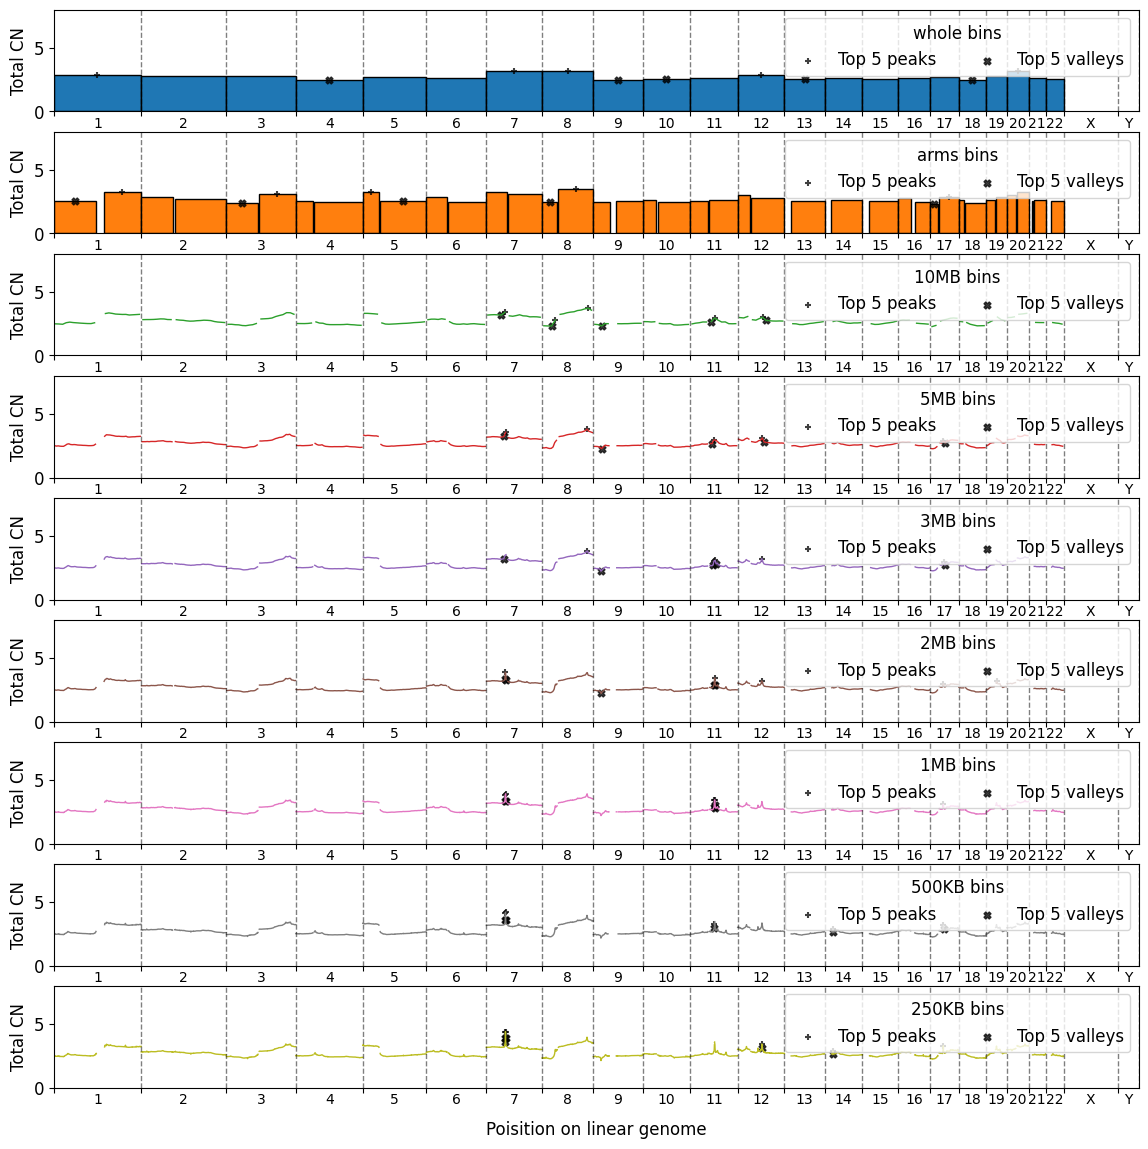

In [30]:
fig, axs = plt.subplots(len(cns_dfs), 1, figsize=(14, 14))

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	group_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	group_df["sample_id"] = f"mean {cancer_type} CN"
	group_df = cns.add_cum_mid(group_df)
	if grouping == "whole":
		group_by = "sample"
	elif grouping == "arms":
		group_by = "chrom"
	else:
		group_by = "cons"
	group_df["score"] = cns.calc_angles(group_df, "total_cn", group_by=group_by)

	if grouping == "whole" or grouping == "arms":
		cns.plot_bars(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	else:
		cns.plot_lines(axs[i], group_df, cn_column="total_cn", color=color_map[i])
	cns.plot_x_lines(axs[i])
	cns.plot_x_ticks(axs[i])

	group_df = group_df.sort_values(by="score")
	axs[i].scatter(group_df["cum_mid"].head(val_count), group_df["total_cn"].head(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} peaks", marker="+")
	axs[i].scatter(group_df["cum_mid"].tail(val_count), group_df["total_cn"].tail(val_count), color="k", alpha=0.75, s=25, label=f"Top {val_count} valleys", marker="X")
	axs[i].set_ylim(0, 8)
	axs[i].set_ylabel("Total CN")
	axs[i].legend(title=f"{grouping} bins", loc="upper right", ncol=3)

axs[-1].set_xlabel("Poisition on linear genome")

cdu.save_cns_fig(f"peaks_valleys_{cancer_type}")

In [31]:
score_means = []

for i, (grouping, cns_df) in enumerate(cns_dfs.items()):
	# skip if does not start with a number
	if grouping[0].isalpha():
		continue
	sel_df = cns.select_cns_by_type(cns_df, samples_df, cancer_type) if cancer_type != "all" else cns_df
	sel_df = cns.group_samples(cns.only_aut(cns.add_total_cn(sel_df)))
	sel_df["sample_id"] = f"mean {cancer_type} CN"
	sel_df["score"] = cns.calc_angles(sel_df, "total_cn")	
	score_means.append(cns.mean_value_per_seg(sel_df, ensembl, "score"))

mean_dfs = {}
mean_df = score_means[0].copy()
for vals in score_means[1:]:
	mean_df["score"] += vals["score"]
mean_df["score"] /= len(score_means)
mean_df["total_cn"] = cns.mean_value_per_seg(sel_df, ensembl, "total_cn")["total_cn"]
mean_df = pd.merge(mean_df, cosmic_df, how="left")

print(mean_df[~mean_df["gene"].isna()].sort_values(by="score", ascending=True).head(10))
cns.save_cns(mean_df, cdu.pjoin(cdu.out_path, f"gene_scores_{cancer_type}.tsv"))

      chrom      start        end             name     score  total_cn  \
18498  chr8  128747679  128753674  ENSG00000136997 -1.137222  3.975192   
17294  chr7   55086713   55324313  ENSG00000146648 -1.114962  4.418679   
18515  chr8  134249413  134314265  ENSG00000104419 -0.918957  3.632211   
18455  chr8  118806728  119124092  ENSG00000182197 -0.908125  3.632654   
18451  chr8  117858173  117887105  ENSG00000164754 -0.902099  3.622083   
18519  chr8  139142265  139509065  ENSG00000147724 -0.858929  3.588626   
18446  chr8  113235156  114449328  ENSG00000164796 -0.852672  3.580629   
18406  chr8  101698043  101735037  ENSG00000070756 -0.841706  3.581757   
18434  chr8  108911543  109095913  ENSG00000147655 -0.839626  3.568327   
18435  chr8  109213444  109447562  ENSG00000104408 -0.838709  3.565467   

          gene  
18498      MYC  
17294     EGFR  
18515    NDRG1  
18455     EXT1  
18451    RAD21  
18519  FAM135B  
18446    CSMD3  
18406   PABPC1  
18434    RSPO2  
18435    EIF3E 

In [32]:
ordered_df = mean_df.sort_values(by=["score"], ascending=False)
ordered_df["score"].sum()
tsgs_df = ordered_df.query("score > 0")[["chrom", "start", "end", "name", "score"]].copy()
print(tsgs_df["score"].describe())
print(tsgs_df["score"].sum())
tsgs_df.to_csv(cdu.pjoin(cdu.out_path, "tsgs_cnsistent_full.tsv"), sep="\t", index=False, header=False)
ogs_df = ordered_df.query("score <= 0")[["chrom", "start", "end", "name", "score"]].copy()
ogs_df["score"] = -ogs_df["score"] 
print(ogs_df["score"].describe())
print(ogs_df["score"].sum())
ogs_df.to_csv(cdu.pjoin(cdu.out_path, "ogs_cnsistent_full.tsv"), sep="\t", index=False, header=False)

count    11106.000000
mean         0.199568
std          0.105798
min          0.000195
25%          0.131781
50%          0.203027
75%          0.264958
max          0.503863
Name: score, dtype: float64
2216.401245266164
count    8324.000000
mean        0.279091
std         0.230237
min         0.000138
25%         0.086424
50%         0.207419
75%         0.480488
max         1.137222
Name: score, dtype: float64
2323.1556474081067


In [ ]:

for group in ["all", "LUAD", "LUSC", "KIRC", "PRAD", "BRCA", "OV" ]:
	score_df = pd.read_csv(cdu.pjoin(cdu.out_path, f"gene_scores_{group}.tsv"), sep="\t")
	ordered_df = score_df.sort_values(by=["score"], ascending=False)
	ordered_df["score"].sum()
	tsgs_df = ordered_df.query("score > 0")[["chrom", "start", "end", "name", "score"]].copy()
	print(tsgs_df["score"].describe())
	print(tsgs_df["score"].sum())
	tsgs_df.to_csv(cdu.pjoin(cdu.out_path, f"tsgs_cnsistent_{group}.tsv"), sep="\t", index=False, header=False)
	ogs_df = ordered_df.query("score <= 0")[["chrom", "start", "end", "name", "score"]].copy()
	ogs_df["score"] = -ogs_df["score"] 
	print(ogs_df["score"].describe())
	print(ogs_df["score"].sum())
	ogs_df.to_csv(cdu.pjoin(cdu.out_path, f"ogs_cnsistent_{group}.tsv"), sep="\t", index=False, header=False)